## Decision tree Regressor

### Importing pipelines and libraries

In [3]:
import sys
sys.path.append(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken")
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import add_features
from src.pipelines import get_pipeline
from src.evalute import print_scores

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

### Loading train and test data sets

In [7]:
train_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\train.csv")
test_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\test.csv")

In [8]:
train_df = clean_data(train_df)
test_df = clean_data(test_df)

train_df = add_features(train_df)
test_df = add_features(test_df)

Column 'Time_taken(min)' not found in DataFrame!


### Defining Target feature and other features

In [9]:
target = "Time_taken(min)"

# Drop rows where target is missing
train_df = train_df.dropna(subset=[target])

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "distance_km",
    "order_to_pickup_time",
    "order_hour",
    "is_weekend"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

X = train_df[numeric_features + categorical_features]
y = train_df[target]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Fitting pipeline 

In [11]:
dt = DecisionTreeRegressor(random_state=42)

dt_pipeline = get_pipeline(dt, numeric_features, categorical_features)

### Hyperparameter tuning

In [14]:
param_grid = {
    "regressor__max_depth": [3, 5, 10, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [15]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Delivery_person_Age',
                                                                          'Delivery_person_Ratings',
                                                                          'multiple_deliveries',
                                                                          'distance_km',
                                                                          'order_to_pickup_time',
                                                                          'order_hour',
                                                                          'is_weekend']),
                                                                        ('cat',
                                                                         Pipeline(steps=[(...
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Weatherconditions',
                                                                          'Road_traffic_density',
                                                                          'Type_of_order',
                                                                          'Type_of_vehicle',
                                                                          'Festival',
                                                                          'City'])])),
                                       ('regressor',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [3, 5, 10, None],
                         'regressor__min_samples_leaf': [1, 2, 5],
                         'regressor__min_samples_split': [2, 5, 10]},
             scoring='r2')

In [16]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 2}
Best CV Score: 0.7498252105205669


### Evalute the model

In [17]:
best_model = grid.best_estimator_
print_scores(best_model, X_train, y_train, X_test, y_test)

Train MAE: 3.4802144482761834
Test MAE: 3.6730647130064886
Train MSE: 20.005989944934257
Test MSE: 22.03226136744375
Train R2: 0.7730398370350149
Test R2: 0.7487143067878741


### visualizing the tree

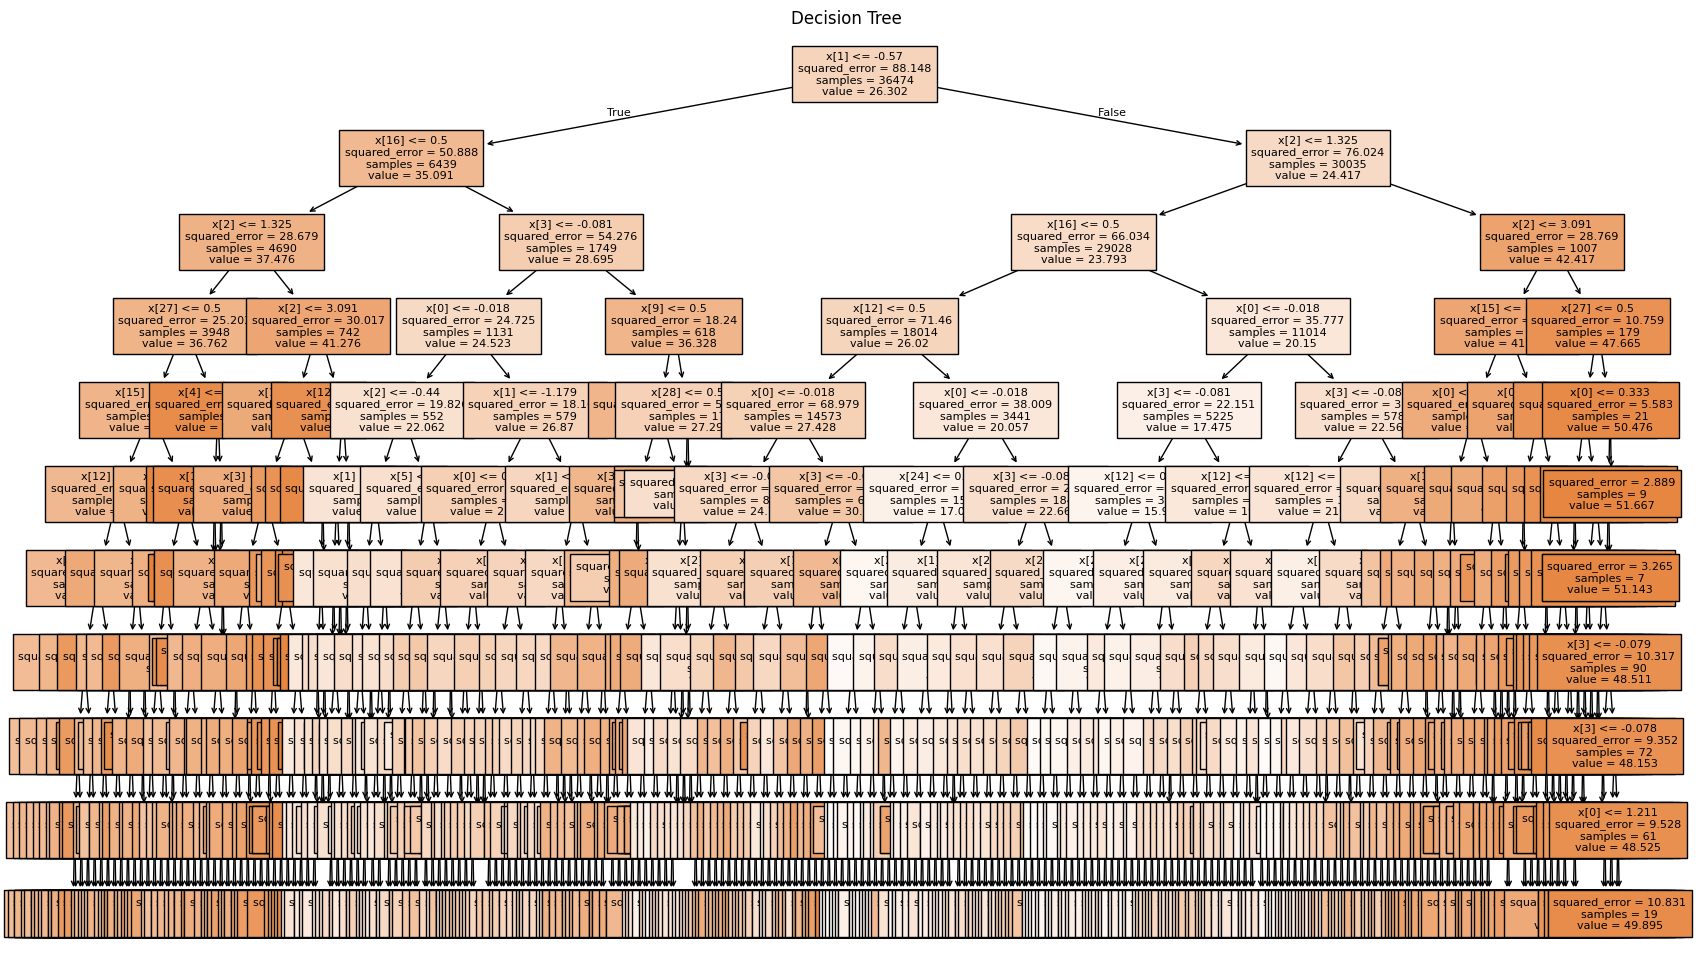

In [26]:
import matplotlib.pyplot as plt
final_tree = best_model.named_steps["regressor"]

plt.figure(figsize=(20,12))
tree.plot_tree(final_tree, filled=True, max_depth=10, fontsize=8)
plt.title("Decision Tree")
plt.show()


### Visualizing the regression curve

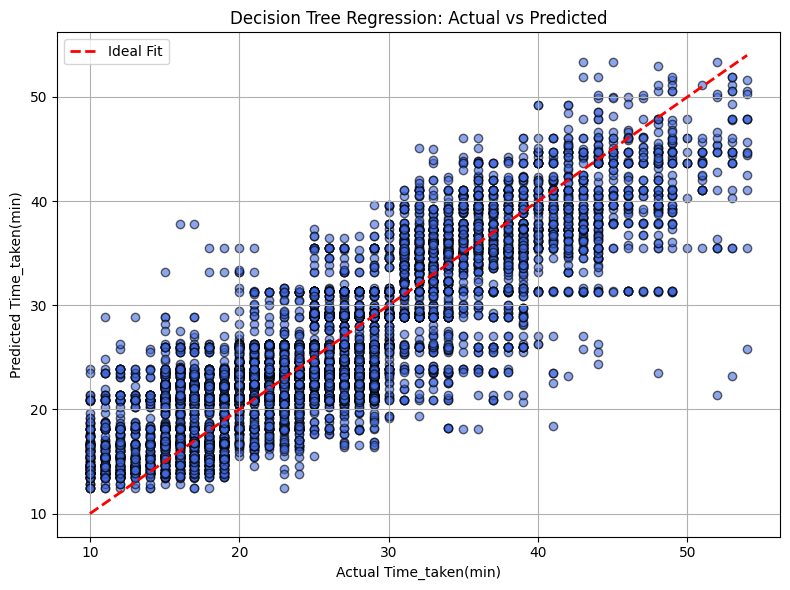

In [27]:
y_pred = best_model.predict(X_test)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Time_taken(min)')
plt.ylabel('Predicted Time_taken(min)')
plt.title('Decision Tree Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()